In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, accuracy_score, roc_auc_score

In [112]:
df = pd.read_csv('new_one.csv')

In [113]:
# add dummies for room type
prop_type_dummies = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)
# add dummies to the main dataframe
df = pd.concat([df, prop_type_dummies], axis=1)

room_type_params = list(prop_type_dummies.columns)[:-1]

df = df.loc[:, ~df.columns.duplicated()]

In [114]:
# define variables for initial model
# parameters of property characteristics
prop_params = ['bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'instant_bookable', 'price', 'accommodates'] 
prop_params += room_type_params

# parameters of host characteristics
host_params = ['host_total_listings_count', 'host_tenure_days', 'host_is_superhost']

# parameters of reviews characteristics
reviews_params = ['number_of_reviews', 'review_scores_rating', 'reviews_last_year', 'reviews_per_month']

# parameters of location characteristics
loc_params = ['distance_to_city_center']

In [115]:
parameters = prop_params + host_params + reviews_params + loc_params

In [116]:
X = df[parameters]
y = df['occupancy'] 
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     42.00
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          5.01e-144
Time:                        19:33:11   Log-Likelihood:                -3395.7
No. Observations:               11795   AIC:                             6829.
Df Residuals:                   11776   BIC:                             6970.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [117]:
aic = {}
y = df["occupancy"]
parameters = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[parameters]
    x = sm.add_constant(x)
    model_current = sm.OLS(y, x).fit()
    aic["baseline"] =  model_current.aic
    for col in df[parameters]:
        y = df["occupancy"]
        candidate_params = parameters.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.OLS(y, x).fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        parameters.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df

,excluded_variable,p_value_at_excluding,AIC_before,AIC_after
0,number_of_reviews,0.945125,6829.450728,6827.455473
1,reviews_per_month,0.698081,6827.455473,6825.606185
2,bathrooms,0.238289,6825.606185,6824.998937


In [118]:
X = df[parameters]
y = df['occupancy']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     50.30
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          3.12e-146
Time:                        19:33:11   Log-Likelihood:                -3396.5
No. Observations:               11795   AIC:                             6825.
Df Residuals:                   11779   BIC:                             6943.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [119]:
parameters = prop_params + host_params + reviews_params + loc_params

In [120]:

X = df[parameters]
X = sm.add_constant(X)

model = sm.GLM(
    df['occupancy'],
    X,
    family=sm.families.Binomial()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              occupancy   No. Observations:                11795
Model:                            GLM   Df Residuals:                    11776
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6348.1
Date:                Wed, 08 Apr 2026   Deviance:                       6003.2
Time:                        19:33:12   Pearson chi2:                 5.15e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02775
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [121]:
aic = {}
y = df["occupancy"]
parameters = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[parameters]
    x = sm.add_constant(x)
    model_current = sm.GLM(y, x, family=sm.families.Binomial()).fit()
    aic["baseline"] =  model_current.aic
    for col in df[parameters]:
        y = df["occupancy"]
        candidate_params = parameters.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.GLM(y, x, family=sm.families.Binomial()).fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        parameters.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df

,excluded_variable,p_value_at_excluding,AIC_before,AIC_after
0,number_of_reviews,0.971738,12734.212841,12732.214096
1,reviews_per_month,0.831415,12732.214096,12730.259337
2,bathrooms,0.431521,12730.259337,12728.880187
3,host_is_superhost,0.210467,12728.880187,12728.448973
4,distance_to_city_center,0.161489,12728.448973,12728.415900


In [122]:

X = df[parameters]
X = sm.add_constant(X)

model = sm.GLM(
    df['occupancy'],
    X,
    family=sm.families.Binomial()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              occupancy   No. Observations:                11795
Model:                            GLM   Df Residuals:                    11781
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6350.2
Date:                Wed, 08 Apr 2026   Deviance:                       6007.4
Time:                        19:33:14   Pearson chi2:                 5.15e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02740
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [123]:
df['high_occupancy'] = (df['occupancy'] > df['occupancy'].median()).astype(int)

In [124]:
parameters = prop_params + host_params + reviews_params + loc_params

In [125]:
# logit model with high_occupancy as target variable
X = df[parameters]
y = df['high_occupancy']
X = sm.add_constant(X)
model_logit = sm.Logit(y, X).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.671346
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         high_occupancy   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11776
Method:                           MLE   Df Model:                           18
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.03145
Time:                        19:33:14   Log-Likelihood:                -7918.5
converged:                       True   LL-Null:                       -8175.7
Covariance Type:            nonrobust   LLR p-value:                 1.051e-97
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.5887      0.386     -4.119      0.000      -2.

In [126]:
aic = {}
y = df["high_occupancy"]
parameters = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[parameters]
    x = sm.add_constant(x)
    model_current = sm.Logit(y, x).fit()
    aic["baseline"] =  model_current.aic
    for col in df[parameters]:
        y = df["occupancy"]
        candidate_params = parameters.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.Logit(y, x).fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        parameters.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df

Optimization terminated successfully.
         Current function value: 0.671346
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656150
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.657529
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656409
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.658247
         Iterations 6


Optimization terminated successfully.
         Current function value: 0.659671
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.658379
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.657157
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656368
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656217
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656356
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656585
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.657780
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656227
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656109
  

,excluded_variable,p_value_at_excluding,AIC_before,AIC_after
0,number_of_reviews,0.494540,15875.055036,15513.613068
1,reviews_per_month,0.831415,15513.613068,15511.818691
2,bathrooms,0.431521,15511.818691,15510.803758


In [127]:
X = df[parameters]
y = df['high_occupancy']
X = sm.add_constant(X)
model_logit = sm.Logit(y, X).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.671452
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         high_occupancy   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11779
Method:                           MLE   Df Model:                           15
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.03130
Time:                        19:33:15   Log-Likelihood:                -7919.8
converged:                       True   LL-Null:                       -8175.7
Covariance Type:            nonrobust   LLR p-value:                 1.853e-99
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.6436      0.384     -4.280      0.000      -2.

In [128]:
df["p_hat"] = model_logit.predict(X)
df["high_occupancy_pred"] = (df["p_hat"] >= 0.5).astype(int)

cm = confusion_matrix(df["high_occupancy"], df["high_occupancy_pred"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix:")
display(cm_df)

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3503,2405
Actual 1,2414,3473


In [129]:
accuracy = accuracy_score(df["high_occupancy"], df["high_occupancy_pred"])
sensativity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Sensitivity", "Specificity"],
    "Value": [accuracy, sensativity, specificity]
})

display(metrics_df.round(4))

,Metric,Value
0,Accuracy,0.5914
1,Sensitivity,0.5899
2,Specificity,0.5929


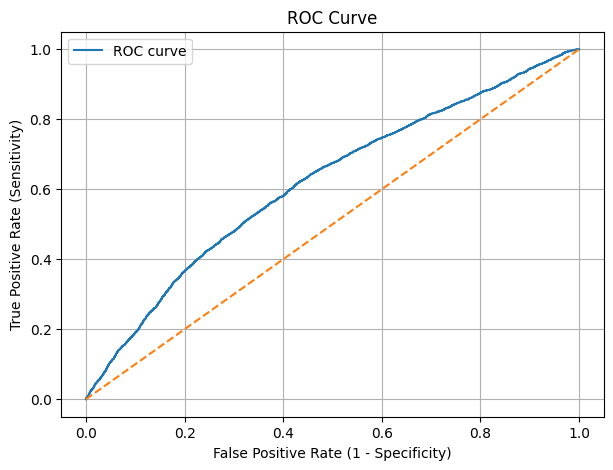

In [130]:
y_true = df["high_occupancy"]
y_score = df["p_hat"]

fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [131]:

auc = roc_auc_score(df["high_occupancy"], df["p_hat"])
print(f"AUC: {auc:.4f}")

AUC: 0.6193


In [132]:
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print("Optimal threshold by Youden's J:", best_threshold)

Optimal threshold by Youden's J: 0.4896025205509919


In [133]:
df["p_hat"] = model_logit.predict(X)
df["high_occupancy_pred_best"] = (df["p_hat"] >= best_threshold).astype(int)

cm_best = confusion_matrix(df["high_occupancy"], df["high_occupancy_pred_best"])

cm_df_best = pd.DataFrame(
    cm_best,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
print("Old Confusion Matrix:")
display(cm_df)
print("Confusion Matrix:")
display(cm_df_best)

Old Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3503,2405
Actual 1,2414,3473


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3341,2567
Actual 1,2217,3670
